In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mamdouhsamir/world-internet-users/world-internet-users.csv
/kaggle/input/datasets/mamdouhsamir/historical-world-population/historical-world-population.csv


In [2]:
#World internet users

import pandas as pd
import matplotlib.pyplot as plt
internet = pd.read_csv('/kaggle/input/datasets/mamdouhsamir/world-internet-users/world-internet-users.csv')
internet #display the dataframe




,year,internet_users
0,1990,3000000
1,1991,4000000
2,1992,7000000
3,1993,10000000
4,1994,20000000
5,1995,39000000
6,1996,77000000
7,1997,120000000
8,1998,188000000
9,1999,281000000


In [3]:
#Find rows where internet_users > 100 million.
#Show first result.

exceeds_100M = internet.query('internet_users > 100e6')
exceeds_100M.head(1)


,year,internet_users
7,1997,120000000


In [4]:
#World population data

#Load population data.
#Display the DataFrame.

population = pd.read_csv('/kaggle/input/datasets/mamdouhsamir/historical-world-population/historical-world-population.csv')
population #display it


,year,population
0,-10000,4501152
1,-9000,5687125
2,-8000,7314623
3,-7000,9651703
4,-6000,13278309
...,...,...
120,2018,7729902724
121,2019,7811293714
122,2020,7887001284
123,2021,7954448405


In [5]:
#Merge the data

#Merge internet and population data.
#Use a left merge on the 'year' column.
#Display the results.

df = internet.merge(population, on='year', how='left')
df #display


,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
3,1993,10000000,5.591545e+09
4,1994,20000000,5.675551e+09
5,1995,39000000,5.758879e+09
6,1996,77000000,5.842056e+09
7,1997,120000000,5.924788e+09
8,1998,188000000,6.007067e+09
9,1999,281000000,6.089006e+09


In [6]:
#Drop rows with NaNs.
#Display the dataframe.

df = df.dropna()
df #display it



,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
3,1993,10000000,5.591545e+09
4,1994,20000000,5.675551e+09
5,1995,39000000,5.758879e+09
6,1996,77000000,5.842056e+09
7,1997,120000000,5.924788e+09
8,1998,188000000,6.007067e+09
9,1999,281000000,6.089006e+09


In [7]:
#Percent of world using internet

#Calculate percent connected to internet.
#Round it to 2 decimal places.
#Display the dataframe.

df['percent'] = df.eval('internet_users/population * 100')
df['percent'] = df['percent'].round(2)
df #display the result



/tmp/ipykernel_16/821540663.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['percent'] = df.eval('internet_users/population * 100')
/tmp/ipykernel_16/821540663.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['percent'] = df['percent'].round(2)


,year,internet_users,population,percent
0,1990,3000000,5.327803e+09,0.06
1,1991,4000000,5.418736e+09,0.07
2,1992,7000000,5.505990e+09,0.13
3,1993,10000000,5.591545e+09,0.18
4,1994,20000000,5.675551e+09,0.35
5,1995,39000000,5.758879e+09,0.68
6,1996,77000000,5.842056e+09,1.32
7,1997,120000000,5.924788e+09,2.03
8,1998,188000000,6.007067e+09,3.13
9,1999,281000000,6.089006e+09,4.61


Text(0, 0.5, 'Percent Connected')

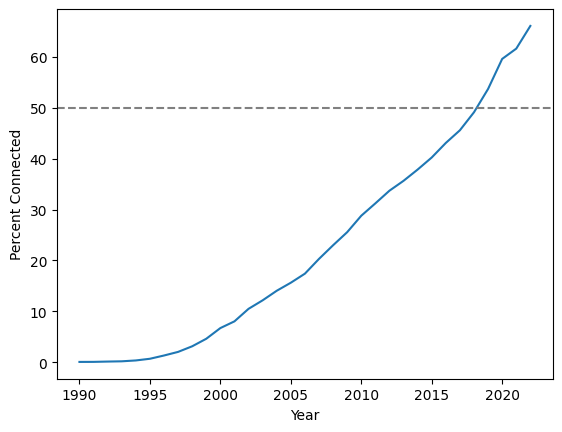

In [8]:
#Half the world connected
#Plot percent connected over time.
#Add a gray horizontal line at 50%.
#Label both axes.

import matplotlib.pyplot as plt
plt.plot(df['year'], df['percent'])
plt.axhline(50, color='gray', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Percent Connected')


In [9]:
#Finding the 50% year

#Find all rows with percent ≥ 50.
#Show just the first row where this happens.

over_half_connected = df.query('percent >= 50')
over_half_connected.head(1)



,year,internet_users,population,percent
29,2019,4194000000,7.811294e+09,53.69
